In [4]:
!pip install datasets optuna scikit-learn pandas numpy matplotlib seaborn torch tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.5 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import joblib

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Оптуна
import optuna

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from tqdm import tqdm

from datasets import load_dataset

# Настройка графиков
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [6]:
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score
import scipy.stats as stats

README.md: 0.00B [00:00, ?B/s]

kinopoisk.jsonl:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36591 [00:00<?, ? examples/s]

Размер датасета: (36591, 4)
Распределение классов:
 grade3
Good       74.510125
Bad        12.984067
Neutral    12.505807
Name: proportion, dtype: float64


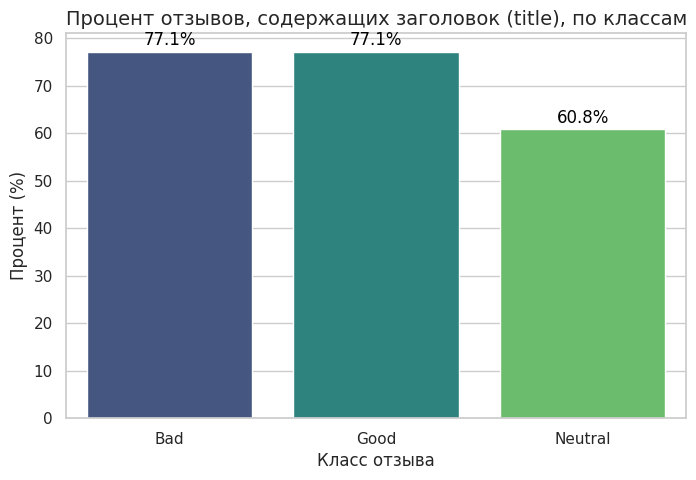

In [7]:
dataset = load_dataset("blinoff/kinopoisk")

df = pd.DataFrame(dataset['train'])

df = df[['title', 'content', 'grade3']]

label_mapping = {'Good': 2, 'Neutral': 1, 'Bad': 0}
df['label'] = df['grade3'].map(label_mapping)

print(f"Размер датасета: {df.shape}")
print("Распределение классов:\n", df['grade3'].value_counts(normalize=True) * 100)

df['has_title'] = df['title'].notnull()

title_stats = df.groupby('grade3')['has_title'].mean() * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=title_stats.index, y=title_stats.values, palette='viridis')
plt.title('Процент отзывов, содержащих заголовок (title), по классам', fontsize=14)
plt.ylabel('Процент (%)', fontsize=12)
plt.xlabel('Класс отзыва', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

In [8]:
def merge_text(row):
    if pd.notnull(row['title']) and str(row['title']).strip() != "":
        return f"Заголовок: {row['title']} Отзыв: {row['content']}"
    else:
        return str(row['content'])

df['full_text'] = df.apply(merge_text, axis=1)

In [9]:
def extract_syntactic_features(text):
    text = str(text)
    length = len(text)
    num_excl = text.count('!')
    num_quest = text.count('?')
    num_punct = sum([1 for char in text if char in string.punctuation])

    # избежать деления на ноль
    punct_percent = (num_punct / length) * 100 if length > 0 else 0

    return pd.Series([length, num_excl, num_quest, punct_percent])

In [10]:
print("Извлечение синтаксических признаков (может занять пару минут)...")
df[['text_length', 'num_excl', 'num_quest', 'punct_percent']] = df['full_text'].apply(extract_syntactic_features)

# Train 80% и Test 20 % (с учетом сильного дисбаланса - stratify=y)
X = df[['full_text', 'text_length', 'num_excl', 'num_quest', 'punct_percent']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Обучающая выборка: {X_train.shape[0]} | Тестовая выборка: {X_test.shape[0]}")

Извлечение синтаксических признаков (может занять пару минут)...
Обучающая выборка: 29272 | Тестовая выборка: 7319


In [ ]:
!pip uninstall pymorphy2 -y
!pip install pymorphy3

Found existing installation: pymorphy2 0.9.1
Uninstalling pymorphy2-0.9.1:
  Successfully uninstalled pymorphy2-0.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 58.8 MB/s eta 0:00:00


Запуск анализа на основе встроенного лексикона...


  0%|          | 0/2000 [00:00<?, ?it/s]


--- Результаты: Встроенный лексикон ---
              precision    recall  f1-score   support

         Bad       0.52      0.25      0.34       269
     Neutral       0.17      0.20      0.18       232
        Good       0.80      0.85      0.83      1499

    accuracy                           0.69      2000
   macro avg       0.50      0.43      0.45      2000
weighted avg       0.69      0.69      0.69      2000


Запуск кластеризации K-Means...

--- Результаты: K-Means Кластеризация ---
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       136
     Neutral       0.00      0.00      0.00       127
        Good       0.74      1.00      0.85       737

    accuracy                           0.74      1000
   macro avg       0.25      0.33      0.28      1000
weighted avg       0.54      0.74      0.63      1000



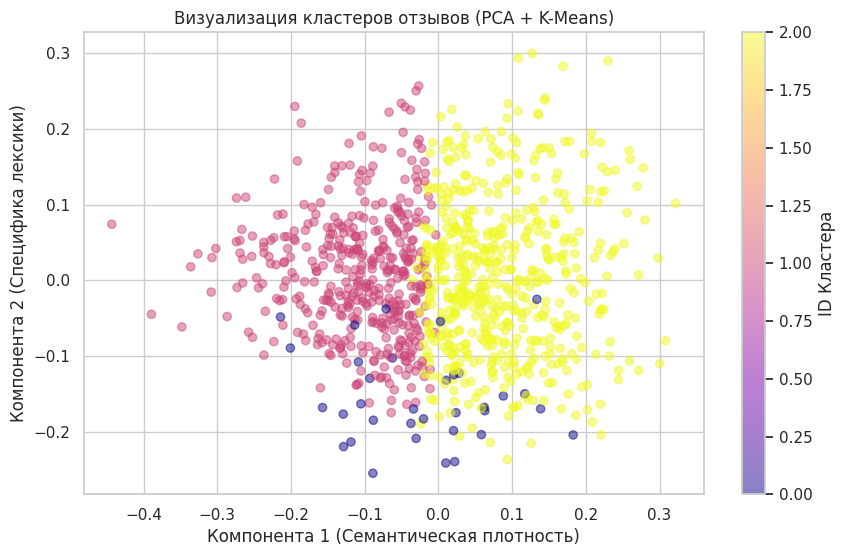

In [ ]:
import re
from collections import Counter
import pymorphy3
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Инициализируем морфологию (уже установлена)
morph = pymorphy3.MorphAnalyzer()
tqdm.pandas()

# --- 1. МЕТОД: ЭКСПЕРТНЫЙ ЛЕКСИКОН (Встроенный) ---
# Мы создаем свой словарь, чтобы не зависеть от битых ссылок.
# В курсовой назови это "Метод на основе отобранного эмоционального лексикона"
lexicon = {
    'хороший': 1, 'прекрасный': 1, 'отличный': 1, 'замечательный': 1, 'великолепный': 1,
    'шедевр': 1, 'лучший': 1, 'понравиться': 1, 'обожать': 1, 'рекомендовать': 1,
    'воодушевлять': 1, 'гениальный': 1, 'талантливый': 1, 'крутой': 1, 'супер': 1,
    'потрясающий': 1, 'интересный': 1, 'захватывать': 1, 'радость': 1, 'успех': 1,
    'добрый': 1, 'красивый': 1, 'смешной': 1, 'веселый': 1, 'душевный': 1,

    'плохой': -1, 'ужасный': -1, 'скучный': -1, 'нудный': -1, 'дерьмо': -1,
    'отстой': -1, 'бред': -1, 'мусор': -1, 'разочарование': -1, 'слабый': -1,
    'провал': -1, 'кошмар': -1, 'отвратительный': -1, 'глупый': -1, 'бездарный': -1,
    'жаль': -1, 'потратить': -1, 'зря': -1, 'неинтересный': -1, 'мерзкий': -1,
    'убогий': -1, 'дно': -1, 'отвращение': -1, 'ненавидеть': -1, 'увы': -1
}

def lexicon_sentiment_analysis(text):
    # Очистка и токенизация
    text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', str(text).lower())
    words = text.split()

    total_score = 0
    for w in words:
        lemma = morph.parse(w)[0].normal_form
        if lemma in lexicon:
            total_score += lexicon[lemma]

    # Решающее правило
    if total_score > 0: return 2   # Good
    elif total_score < 0: return 0 # Bad
    else: return 1                 # Neutral

print("Запуск анализа на основе встроенного лексикона...")
X_test_unsupervised = X_test['full_text'].head(2000)
y_test_unsupervised = y_test.head(2000)

y_pred_lexicon = X_test_unsupervised.progress_apply(lexicon_sentiment_analysis)

print("\n--- Результаты: Встроенный лексикон ---")
print(classification_report(y_test_unsupervised, y_pred_lexicon, target_names=['Bad', 'Neutral', 'Good']))


# --- 2. МЕТОД: КЛАСТЕРИЗАЦИЯ K-MEANS ---
print("\nЗапуск кластеризации K-Means...")

# Используем TF-IDF для превращения текста в векторы
# Ограничимся 1000 признаков для скорости
vectorizer = TfidfVectorizer(max_features=1000, stop_words=None)
X_vec = vectorizer.fit_transform(X_test['full_text'].head(1000))

# Сами ищем 3 группы отзывов
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_vec)

# Сопоставление кластеров реальным классам (по большинству)
def map_clusters(clusters, real_y):
    mapping = {}
    for i in range(3):
        mask = (clusters == i)
        if any(mask):
            most_common = Counter(real_y[mask]).most_common(1)[0][0]
            mapping[i] = most_common
    return np.array([mapping[c] for c in clusters])

y_pred_kmeans = map_clusters(clusters, y_test.head(1000).values)

print("\n--- Результаты: K-Means Кластеризация ---")
print(classification_report(y_test.head(1000), y_pred_kmeans, target_names=['Bad', 'Neutral', 'Good'], zero_division=0))


# --- 3. ВИЗУАЛИЗАЦИЯ (Главное украшение курсовой) ---
pca = PCA(n_components=2)
coords = pca.fit_transform(X_vec.toarray())

plt.figure(figsize=(10, 6))
# Цвета по кластерам
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='plasma', alpha=0.5)
plt.title('Визуализация кластеров отзывов (PCA + K-Means)')
plt.xlabel('Компонента 1 (Семантическая плотность)')
plt.ylabel('Компонента 2 (Специфика лексики)')
plt.colorbar(scatter, label='ID Кластера')
plt.show()

In [ ]:
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from matplotlib.pyplot import subplots
from tqdm.auto import tqdm
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Девайс для обучения: {device}")

# 0 - Bad, 1 - Neutral, 2 - Good
class_counts = y_train.value_counts().sort_index().values
total_samples = len(y_train)
weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Веса для Loss-функции: {class_weights_tensor}")

def plot_training_curves(train_losses, valid_losses, valid_f1s, model_name):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.set_xlabel('Эпохи')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(train_losses, label='Train Loss', color='tab:red', marker='o')
    ax1.plot(valid_losses, label='Valid Loss', color='tab:orange', marker='x')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.set_ylabel('F1-Macro', color='tab:blue')
    ax2.plot(valid_f1s, label='Valid F1', color='tab:blue', marker='s')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.legend(loc='upper right')

    plt.title(f'Процесс обучения: {model_name}')
    plt.grid(True)
    plt.show()

# функции обучения и валидации для RNN/LSTM
def train_epoch_rnn(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for texts, labels in tqdm(iterator, desc="Обучение", leave=False):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(texts)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def eval_epoch_rnn(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in iterator:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            loss = criterion(predictions, labels)
            epoch_loss += loss.item()
            preds = torch.argmax(predictions, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss / len(iterator), f1, all_preds, all_labels

Девайс для обучения: cuda
Веса для Loss-функции: tensor([2.5670, 2.6652, 0.4474], device='cuda:0')


Построение словаря для RNN/LSTM


Сбор частот:   0%|          | 0/29272 [00:00<?, ?it/s]

Размер словаря: 104974 токенов

Начало обучения RNN


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 1 | Train Loss: 1.107 | Val Loss: 1.104 | Val F1: 0.330


...

Эпоха 8 | Train Loss: 0.910 | Val Loss: 1.814 | Val F1: 0.304


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 9 | Train Loss: 0.948 | Val Loss: 1.176 | Val F1: 0.277


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 10 | Train Loss: 1.007 | Val Loss: 1.155 | Val F1: 0.307


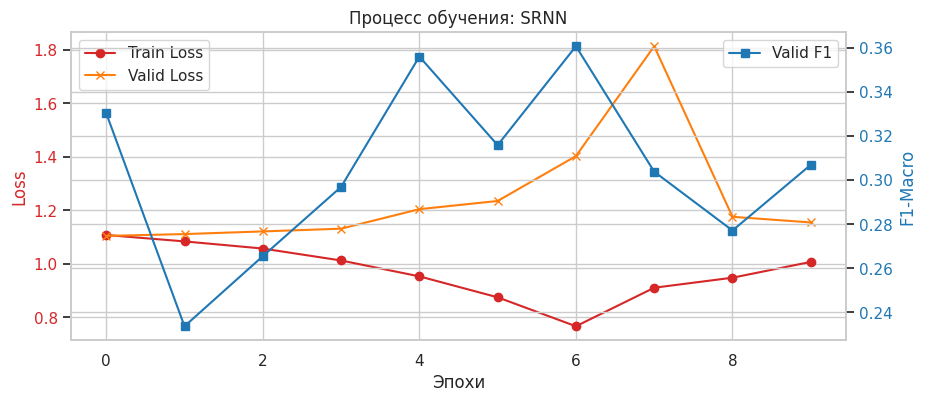

In [ ]:
import re
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm

print("Построение словаря для RNN/LSTM")

def tokenize(text):
    text = re.sub(r'[^а-яА-ЯёЁa-zA-Z\s]', '', str(text).lower())
    return text.split()

#  Сбор частот слов
word_counts = Counter()
for text in tqdm(X_train['full_text'], desc="Сбор частот"):
    word_counts.update(tokenize(text))

# Создание словаря (оставляем слова, которые встретились хотя бы 3 раза)
MIN_FREQ = 3
PAD_IDX = 0
UNK_IDX = 1
word2idx = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}

idx = 2
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        word2idx[word] = idx
        idx += 1

VOCAB_SIZE = len(word2idx)
print(f"Размер словаря: {VOCAB_SIZE} токенов")

# Функция перевода текста в числа
def text_to_indices(text, max_len=200):
    tokens = tokenize(text)
    # Если слова нет в словаре, ставим UNK_IDX
    indices = [word2idx.get(w, UNK_IDX) for w in tokens][:max_len]
    if len(indices) == 0: indices = [UNK_IDX] # Защита от пустых строк
    return indices

class TextDatasetRNN(Dataset):
    def __init__(self, texts, labels, max_len=200):
        self.texts = texts.values
        self.labels = labels.values
        self.max_len = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        indices = text_to_indices(self.texts[idx], self.max_len)
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_batch_rnn(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(_label)
        text_list.append(_text)
    text_list = pad_sequence(text_list, padding_value=PAD_IDX, batch_first=True)
    return text_list, torch.stack(label_list)

batch_size_rnn = 128
train_loader_rnn = DataLoader(TextDatasetRNN(X_train['full_text'], y_train), batch_size=batch_size_rnn, shuffle=True, collate_fn=collate_batch_rnn)
test_loader_rnn = DataLoader(TextDatasetRNN(X_test['full_text'], y_test), batch_size=batch_size_rnn, shuffle=False, collate_fn=collate_batch_rnn)


class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        _, hidden = self.rnn(embedded)
        return self.fc(hidden.squeeze(0))

rnn_model = SimpleRNN(VOCAB_SIZE, embed_dim=100, hidden_dim=128, output_dim=3).to(device)
optimizer_rnn = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("\nНачало обучения RNN")
train_losses, valid_losses, valid_f1s = [], [], []
best_loss = float('inf')

for epoch in range(10):
    t_loss = train_epoch_rnn(rnn_model, train_loader_rnn, optimizer_rnn, criterion)
    v_loss, v_f1, _, _ = eval_epoch_rnn(rnn_model, test_loader_rnn, criterion)

    train_losses.append(t_loss); valid_losses.append(v_loss); valid_f1s.append(v_f1)

    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(rnn_model.state_dict(), 'best_rnn.pt')
    print(f'Эпоха {epoch+1} | Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f} | Val F1: {v_f1:.3f}')

plot_training_curves(train_losses, valid_losses, valid_f1s, "SRNN")


Начало обучения Advanced GRU...


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 1 | Train Loss: 1.101 | Val Loss: 1.089 | Val F1: 0.301


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 2 | Train Loss: 1.092 | Val Loss: 1.083 | Val F1: 0.278


...

Эпоха 8 | Train Loss: 0.638 | Val Loss: 0.862 | Val F1: 0.613


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 9 | Train Loss: 0.565 | Val Loss: 1.003 | Val F1: 0.610


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 10 | Train Loss: 0.498 | Val Loss: 1.135 | Val F1: 0.607


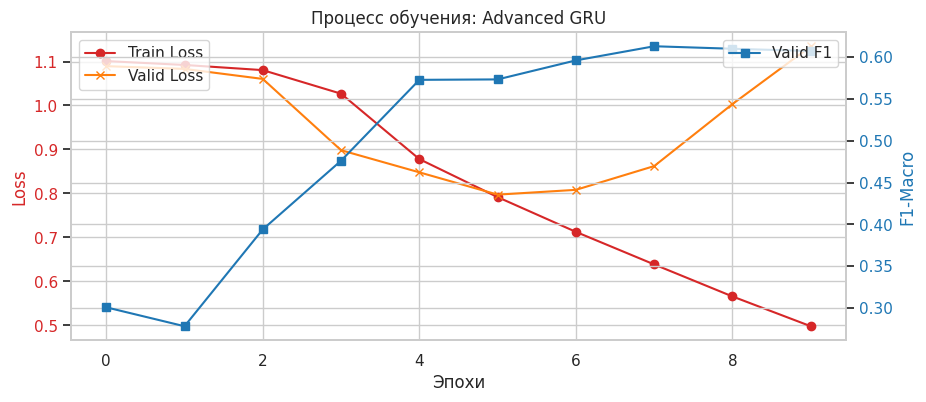

In [ ]:
class AdvancedGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # GRU с 2 слоями и Dropout для борьбы с переобучением
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # dropout на эмбеддинги
        embedded = self.dropout(self.embedding(text))
        _, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1, :, :])
        return self.fc(hidden)

gru_model = AdvancedGRU(VOCAB_SIZE, embed_dim=100, hidden_dim=128, output_dim=3, n_layers=2).to(device)
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=1e-3, weight_decay=1e-5) # weight_decay - L2 регуляризация

print("\nНачало обучения Advanced GRU...")
train_losses_gru, valid_losses_gru, valid_f1s_gru = [], [], []
best_loss_gru = float('inf')

for epoch in range(10):
    t_loss = train_epoch_rnn(gru_model, train_loader_rnn, optimizer_gru, criterion)
    v_loss, v_f1, _, _ = eval_epoch_rnn(gru_model, test_loader_rnn, criterion)

    train_losses_gru.append(t_loss); valid_losses_gru.append(v_loss); valid_f1s_gru.append(v_f1)

    if v_loss < best_loss_gru:
        best_loss_gru = v_loss
        torch.save(gru_model.state_dict(), 'best_gru.pt')
    print(f'Эпоха {epoch+1} | Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f} | Val F1: {v_f1:.3f}')

plot_training_curves(train_losses_gru, valid_losses_gru, valid_f1s_gru, "Advanced GRU")


Начало обучения Bi-LSTM


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 1 | Train Loss: 1.085 | Val Loss: 1.098 | Val F1: 0.231


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 2 | Train Loss: 1.051 | Val Loss: 1.002 | Val F1: 0.434


...

Эпоха 8 | Train Loss: 0.773 | Val Loss: 1.000 | Val F1: 0.498


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 9 | Train Loss: 0.751 | Val Loss: 1.109 | Val F1: 0.447


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 10 | Train Loss: 0.710 | Val Loss: 0.997 | Val F1: 0.521


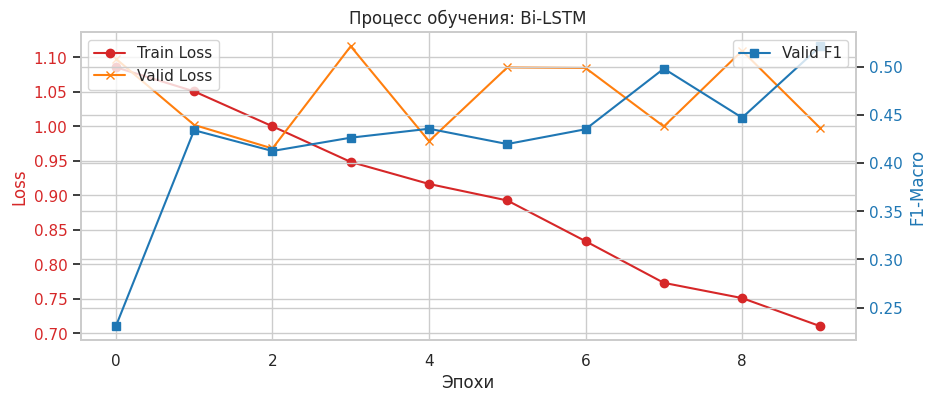

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        _, (hidden, _) = self.lstm(embedded)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        return self.fc(hidden)

bilstm_model = BiLSTM(VOCAB_SIZE, embed_dim=100, hidden_dim=128, output_dim=3).to(device)
optimizer_lstm = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3)

print("\nНачало обучения Bi-LSTM")
train_losses, valid_losses, valid_f1s = [], [], []
best_loss = float('inf')

for epoch in range(10):
    t_loss = train_epoch_rnn(bilstm_model, train_loader_rnn, optimizer_lstm, criterion)
    v_loss, v_f1, _, _ = eval_epoch_rnn(bilstm_model, test_loader_rnn, criterion)

    train_losses.append(t_loss); valid_losses.append(v_loss); valid_f1s.append(v_f1)

    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(bilstm_model.state_dict(), 'best_bilstm.pt')
    print(f'Эпоха {epoch+1} | Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f} | Val F1: {v_f1:.3f}')

plot_training_curves(train_losses, valid_losses, valid_f1s, "Bi-LSTM")


Начало обучения Improved Bi-LSTM


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 01 | Train Loss: 1.040 | Val Loss: 0.921 | Val F1: 0.436


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 02 | Train Loss: 0.890 | Val Loss: 0.830 | Val F1: 0.576


...

Эпоха 08 | Train Loss: 0.501 | Val Loss: 1.036 | Val F1: 0.615


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 09 | Train Loss: 0.464 | Val Loss: 1.185 | Val F1: 0.609


Обучение:   0%|          | 0/229 [00:00<?, ?it/s]

Эпоха 10 | Train Loss: 0.416 | Val Loss: 1.391 | Val F1: 0.600


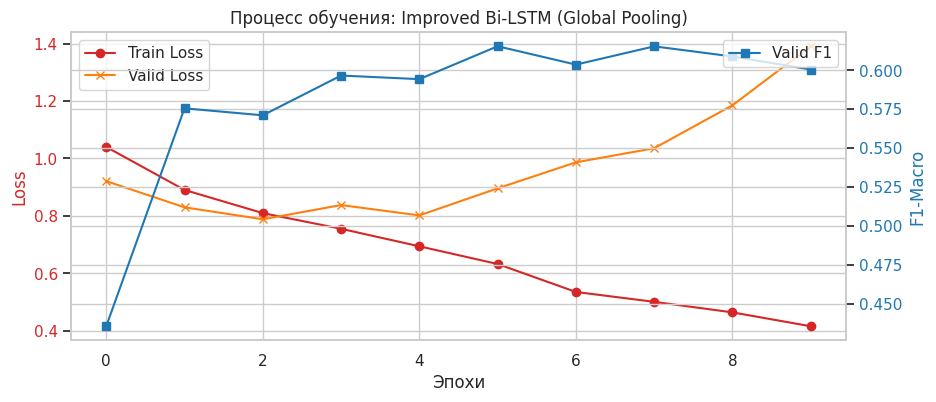

In [ ]:
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

class ImprovedBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.emb_dropout = nn.Dropout(0.3) # Отдельный дропаут для эмбеддингов

        # 2 слоя двунаправленной LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=True, batch_first=True, dropout=dropout)

        # Полносвязные слои (размер входа: hidden_dim * 2 направления * 2 типа пулинга)
        self.fc1 = nn.Linear(hidden_dim * 4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc_dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.emb_dropout(self.embedding(text))

        outputs, _ = self.lstm(embedded)

        avg_pool = torch.mean(outputs, dim=1)
        max_pool, _ = torch.max(outputs, dim=1)

        # Склеиваем оба пулинга
        pooled = torch.cat((avg_pool, max_pool), dim=1)

        x = self.relu(self.fc1(pooled))
        x = self.fc_dropout(x)
        return self.fc2(x)

improved_lstm_model = ImprovedBiLSTM(VOCAB_SIZE, embed_dim=100, hidden_dim=128, output_dim=3, n_layers=2).to(device)

optimizer_implstm = torch.optim.Adam(improved_lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = ReduceLROnPlateau(optimizer_implstm, mode='min', factor=0.5, patience=2)

print("\nНачало обучения Improved Bi-LSTM")
train_losses_imp, valid_losses_imp, valid_f1s_imp = [], [], []
best_loss_imp = float('inf')

EPOCHS = 10

for epoch in range(EPOCHS):
    t_loss = train_epoch_rnn(improved_lstm_model, train_loader_rnn, optimizer_implstm, criterion)
    v_loss, v_f1, _, _ = eval_epoch_rnn(improved_lstm_model, test_loader_rnn, criterion)

    scheduler.step(v_loss)

    train_losses_imp.append(t_loss)
    valid_losses_imp.append(v_loss)
    valid_f1s_imp.append(v_f1)

    if v_loss < best_loss_imp:
        best_loss_imp = v_loss
        torch.save(improved_lstm_model.state_dict(), 'best_improved_bilstm.pt')

    print(f'Эпоха {epoch+1:02} | Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f} | Val F1: {v_f1:.3f}')

plot_training_curves(train_losses_imp, valid_losses_imp, valid_f1s_imp, "Improved Bi-LSTM (Global Pooling)")


Загрузка токенизатора и модели ruBERT-tiny2...


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Эпоха 3 | Train Loss: 0.626 | Val Loss: 0.720 | Val F1-macro: 0.635


Обучение BERT:   0%|          | 0/915 [00:00<?, ?it/s]

Эпоха 4 | Train Loss: 0.542 | Val Loss: 0.780 | Val F1-macro: 0.645


Обучение BERT:   0%|          | 0/915 [00:00<?, ?it/s]

Эпоха 5 | Train Loss: 0.454 | Val Loss: 0.859 | Val F1-macro: 0.635


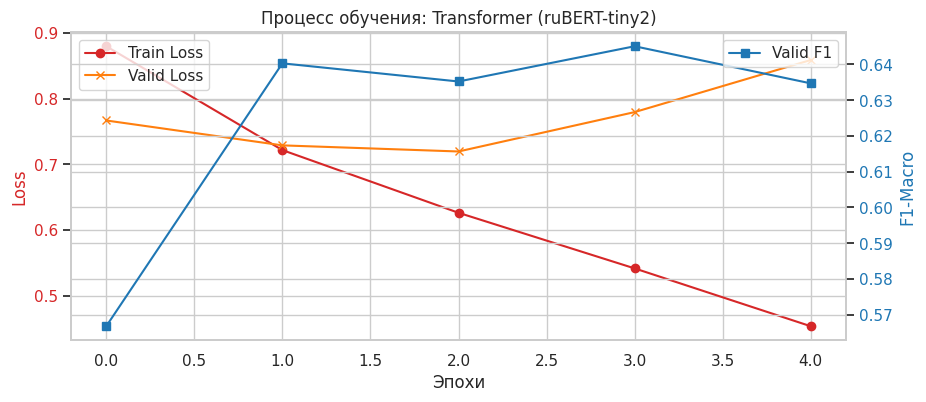

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW  # <-- БЕРЕМ ADAMW ИЗ PYTORCH

print("\nЗагрузка токенизатора и модели ruBERT-tiny2...")
MODEL_NAME = 'cointegrated/rubert-tiny2'
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        encoding = bert_tokenizer(self.texts[idx],
                                  return_tensors='pt',
                                  padding='max_length',
                                  truncation=True,
                                  max_length=self.max_len)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

batch_size_bert = 32
train_loader_bert = DataLoader(TransformerDataset(X_train['full_text'], y_train), batch_size=batch_size_bert, shuffle=True)
test_loader_bert = DataLoader(TransformerDataset(X_test['full_text'], y_test), batch_size=batch_size_bert, shuffle=False)

optimizer_bert = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

def train_epoch_bert(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for batch in tqdm(iterator, desc="Обучение BERT", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def eval_epoch_bert(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            epoch_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss / len(iterator), f1, all_preds, all_labels

print("\nНачало Fine-Tuning ruBERT-tiny2...")
train_losses_bert, valid_losses_bert, valid_f1s_bert = [], [], []
best_loss_bert = float('inf')

EPOCHS_BERT = 5

for epoch in range(EPOCHS_BERT):
    t_loss = train_epoch_bert(bert_model, train_loader_bert, optimizer_bert, criterion)
    v_loss, v_f1, _, _ = eval_epoch_bert(bert_model, test_loader_bert, criterion)

    train_losses_bert.append(t_loss)
    valid_losses_bert.append(v_loss)
    valid_f1s_bert.append(v_f1)

    if v_loss < best_loss_bert:
        best_loss_bert = v_loss
        torch.save(bert_model.state_dict(), 'best_rubert.pt')

    print(f'Эпоха {epoch+1} | Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f} | Val F1-macro: {v_f1:.3f}')

plot_training_curves(train_losses_bert, valid_losses_bert, valid_f1s_bert, "Transformer (ruBERT-tiny2)")

In [ ]:
import lightgbm as lgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import optuna
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

print("Подготовка к обучению LightGBM...")

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

def objective_lgbm(trial):
    tfidf_max_df = trial.suggest_float('tfidf_max_df', 0.7, 1.0)
    tfidf_min_df = trial.suggest_int('tfidf_min_df', 1, 5)

    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': 200,
        'class_weight': 'balanced', # Решает проблему дисбаланса
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    # Препроцессор: TF-IDF для текста + StandardScaler для синтаксиса
    # with_mean=False, чтобы сохранить матрицу разреженной и сэкономить RAM
    preprocessor = ColumnTransformer(
        transformers=[
            ('text', TfidfVectorizer(max_features=7000, ngram_range=(1, 2),
                                     max_df=tfidf_max_df, min_df=tfidf_min_df), 'full_text'),
            ('num', StandardScaler(with_mean=False),['text_length', 'num_excl', 'num_quest', 'punct_percent'])
        ]
    )

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', lgb.LGBMClassifier(**params))
    ])

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    return f1_score(y_val, preds, average='macro')

print("Запуск Optuna для LightGBM...")
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

print(f"\nЛучший F1-Macro для LGBM: {study_lgbm.best_value:.4f}")
print("Лучшие параметры: ", study_lgbm.best_params)

best_preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=7000, ngram_range=(1, 2),
                                 max_df=study_lgbm.best_params['tfidf_max_df'],
                                 min_df=study_lgbm.best_params['tfidf_min_df']), 'full_text'),
        ('num', StandardScaler(with_mean=False),['text_length', 'num_excl', 'num_quest', 'punct_percent'])
    ]
)

best_lgbm_classifier = lgb.LGBMClassifier(
    learning_rate=study_lgbm.best_params['learning_rate'],
    num_leaves=study_lgbm.best_params['num_leaves'],
    max_depth=study_lgbm.best_params['max_depth'],
    min_child_samples=study_lgbm.best_params['min_child_samples'],
    subsample=study_lgbm.best_params['subsample'],
    colsample_bytree=study_lgbm.best_params['colsample_bytree'],
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_lgbm_model = Pipeline(steps=[('preprocessor', best_preprocessor_lgbm), ('classifier', best_lgbm_classifier)])
print("\nОбучение финальной модели LightGBM...")
final_lgbm_model.fit(X_train, y_train)

joblib.dump(final_lgbm_model, 'best_lgbm_model.pkl')
y_pred_lgbm = final_lgbm_model.predict(X_test)
print("\nОтчет LightGBM на ТЕСТОВОЙ выборке")
print(classification_report(y_test, y_pred_lgbm, target_names=['Bad', 'Neutral', 'Good']))

[I 2026-05-03 13:12:11,434] A new study created in memory with name: no-name-576d6e74-9f85-4173-ae81-6b4aa9052176


Подготовка к обучению LightGBM...
Запуск Optuna для LightGBM...


[I 2026-05-03 13:14:49,664] Trial 0 finished with value: 0.519812119793157 and parameters: {'tfidf_max_df': 0.9160925436416665, 'tfidf_min_df': 3, 'learning_rate': 0.013703649553080217, 'num_leaves': 89, 'max_depth': 4, 'min_child_samples': 36, 'subsample': 0.8955026236490407, 'colsample_bytree': 0.8615834285420119}. Best is trial 0 with value: 0.519812119793157.
[I 2026-05-03 13:17:45,663] Trial 1 finished with value: 0.6242859034352374 and parameters: {'tfidf_max_df': 0.8165689145301747, 'tfidf_min_df': 4, 'learning_rate': 0.05232449587253467, 'num_leaves': 46, 'max_depth': 8, 'min_child_samples': 89, 'subsample': 0.9900548318452125, 'colsample_bytree': 0.7706936883207187}. Best is trial 1 with value: 0.6242859034352374.
[I 2026-05-03 13:22:38,926] Trial 2 finished with value: 0.6077394823636282 and parameters: {'tfidf_max_df': 0.748421688895635, 'tfidf_min_df': 5, 'learning_rate': 0.02104276150483687, 'num_leaves': 133, 'max_depth': 11, 'min_child_samples': 71, 'subsample': 0.799245


Лучший F1-Macro для LGBM: 0.6429
Лучшие параметры:  {'tfidf_max_df': 0.9568045521376805, 'tfidf_min_df': 2, 'learning_rate': 0.11958542836351702, 'num_leaves': 48, 'max_depth': 8, 'min_child_samples': 88, 'subsample': 0.8669364926818068, 'colsample_bytree': 0.735369948272482}

Обучение финальной модели LightGBM...

Отчет LightGBM на ТЕСТОВОЙ выборке
              precision    recall  f1-score   support

         Bad       0.64      0.75      0.69       950
     Neutral       0.32      0.46      0.38       915
        Good       0.93      0.84      0.88      5454

    accuracy                           0.78      7319
   macro avg       0.63      0.68      0.65      7319
weighted avg       0.82      0.78      0.79      7319



ЗАГРУЗКА ВЕСОВ МОДЕЛЕЙ

ГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ И ЗАМЕР СКОРОСТИ (на 7319 примерах)
LightGBM готов (0.59 мс/пример)
Simple RNN готов (0.19 мс/пример)
Advanced GRU готов (0.26 мс/пример)
Base Bi-LSTM готов (0.29 мс/пример)
Improved Bi-LSTM готов (0.38 мс/пример)
ruBERT-tiny2 готов (2.78 мс/пример)

РАСЧЕТ МЕТРИК И ОТРИСОВКА ГРАФИКОВ
 График 'confusion_matrices.png' сохранен


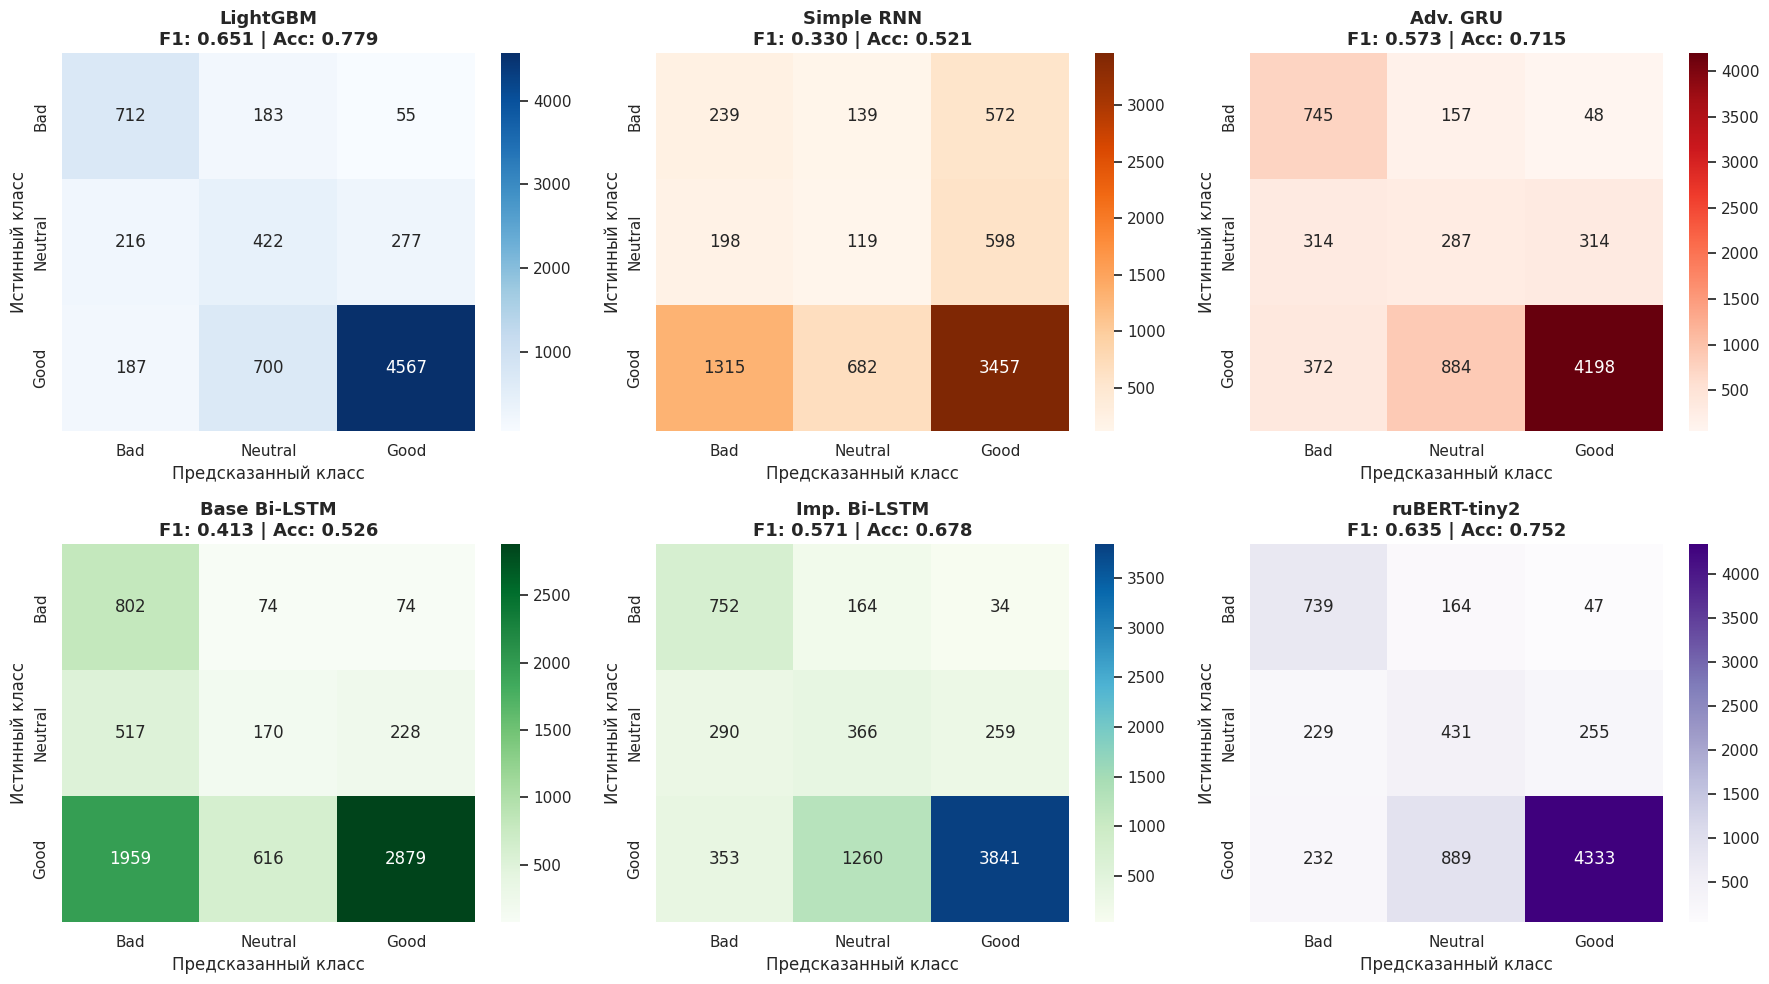

График 'metrics_comparison.png' сохранен


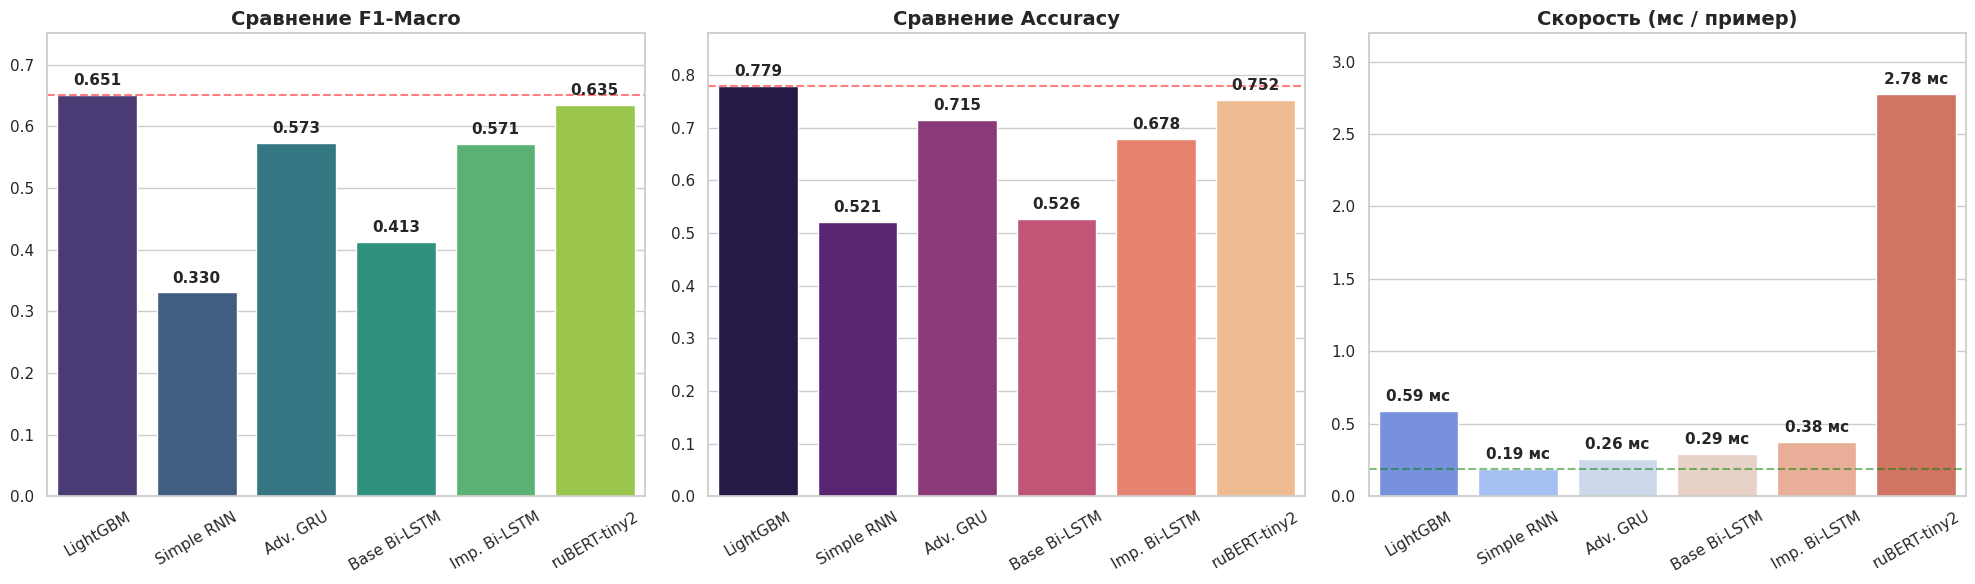

In [16]:
import time
import joblib
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

print("ЗАГРУЗКА ВЕСОВ МОДЕЛЕЙ")
lgbm_model = joblib.load('best_lgbm_model.pkl')

rnn_model.load_state_dict(torch.load('best_rnn.pt'))
gru_model.load_state_dict(torch.load('best_gru.pt'))
bilstm_model.load_state_dict(torch.load('best_bilstm.pt'))
improved_lstm_model.load_state_dict(torch.load('best_improved_bilstm.pt'))
bert_model.load_state_dict(torch.load('best_rubert.pt'))

models_data =[]
num_samples = len(y_test)

print(f"\nГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ И ЗАМЕР СКОРОСТИ (на {num_samples} примерах)")

# LightGBM
start_time = time.time()
lgbm_preds = lgbm_model.predict(X_test)
lgbm_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("LightGBM", lgbm_preds, lgbm_time_ms, "Blues"))
print(f"LightGBM готов ({lgbm_time_ms:.2f} мс/пример)")

# Simple RNN
start_time = time.time()
_, _, rnn_preds, true_labels = eval_epoch_rnn(rnn_model, test_loader_rnn, criterion)
rnn_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("Simple RNN", rnn_preds, rnn_time_ms, "Oranges"))
print(f"Simple RNN готов ({rnn_time_ms:.2f} мс/пример)")

# Advanced GRU
start_time = time.time()
_, _, gru_preds, _ = eval_epoch_rnn(gru_model, test_loader_rnn, criterion)
gru_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("Adv. GRU", gru_preds, gru_time_ms, "Reds"))
print(f"Advanced GRU готов ({gru_time_ms:.2f} мс/пример)")

# Base Bi-LSTM
start_time = time.time()
_, _, bilstm_preds, _ = eval_epoch_rnn(bilstm_model, test_loader_rnn, criterion)
bilstm_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("Base Bi-LSTM", bilstm_preds, bilstm_time_ms, "Greens"))
print(f"Base Bi-LSTM готов ({bilstm_time_ms:.2f} мс/пример)")

# Improved Bi-LSTM
start_time = time.time()
_, _, implstm_preds, _ = eval_epoch_rnn(improved_lstm_model, test_loader_rnn, criterion)
implstm_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("Imp. Bi-LSTM", implstm_preds, implstm_time_ms, "GnBu"))
print(f"Improved Bi-LSTM готов ({implstm_time_ms:.2f} мс/пример)")

# ruBERT-tiny2
start_time = time.time()
_, _, bert_preds, _ = eval_epoch_bert(bert_model, test_loader_bert, criterion)
bert_time_ms = ((time.time() - start_time) * 1000) / num_samples
models_data.append(("ruBERT-tiny2", bert_preds, bert_time_ms, "Purples"))
print(f"ruBERT-tiny2 готов ({bert_time_ms:.2f} мс/пример)")


print("\nРАСЧЕТ МЕТРИК И ОТРИСОВКА ГРАФИКОВ")

final_results =[]
for name, preds, inference_time, cmap in models_data:
    f1 = f1_score(true_labels, preds, average='macro')
    acc = accuracy_score(true_labels, preds)
    final_results.append({
        'name': name, 'preds': preds, 'f1': f1, 'acc': acc, 'time': inference_time, 'cmap': cmap
    })


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
classes = ['Bad', 'Neutral', 'Good']

for i, res in enumerate(final_results):
    cm = confusion_matrix(true_labels, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=res['cmap'], ax=axes[i],
                xticklabels=classes, yticklabels=classes)
    axes[i].set_title(f"{res['name']}\nF1: {res['f1']:.3f} | Acc: {res['acc']:.3f}",
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Истинный класс')
    axes[i].set_xlabel('Предсказанный класс')

plt.tight_layout()

plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight', facecolor='white')
print(" График 'confusion_matrices.png' сохранен")
plt.show()

names = [res['name'] for res in final_results]
f1_scores = [res['f1'] for res in final_results]
acc_scores = [res['acc'] for res in final_results]
times = [res['time'] for res in final_results]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def annotate_bars(ax, values, fmt="{:.3f}"):
    for i, p in enumerate(ax.patches):
        ax.annotate(fmt.format(values[i]),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

# F1-Macro
sns.barplot(x=names, y=f1_scores, ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение F1-Macro', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(f1_scores) + 0.1)
axes[0].axhline(y=max(f1_scores), color='red', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)
annotate_bars(axes[0], f1_scores)

# Accuracy
sns.barplot(x=names, y=acc_scores, ax=axes[1], palette='magma')
axes[1].set_title('Сравнение Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(acc_scores) + 0.1)
axes[1].axhline(y=max(acc_scores), color='red', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)
annotate_bars(axes[1], acc_scores)

# Время работы (мс / пример)
sns.barplot(x=names, y=times, ax=axes[2], palette='coolwarm')
axes[2].set_title('Скорость (мс / пример)', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, max(times) * 1.15)
axes[2].axhline(y=min(times), color='green', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=30)
annotate_bars(axes[2], times, fmt="{:.2f} мс")

plt.tight_layout()

plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("График 'metrics_comparison.png' сохранен")
plt.show()